usage of SegFormer trained on ADE20K for VOC2012, need to finetune on VOC2012 for better performance

In [1]:
import torch
from torchvision.datasets import VOCSegmentation
from transformers import SegformerFeatureExtractor, SegformerForSemanticSegmentation
import matplotlib.pyplot as plt
import numpy as np

/Users/wick/computer_vision/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
    dev = "cuda:0"
elif torch.backends.mps.is_available():
    dev = "mps"
else:
    dev = "cpu"
device = torch.device(dev)
device

device(type='mps')

In [3]:
dataset = VOCSegmentation(
    root=".",
    year="2012",
    image_set="val",
    download=True,
)

In [4]:
feature_extractor = SegformerFeatureExtractor.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
model = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
model.to(device)
model.eval()

/Users/wick/computer_vision/.venv/lib/python3.13/site-packages/transformers/models/segformer/feature_extraction_segformer.py:30: FutureWarning: The class SegformerFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use SegformerImageProcessor instead.
  warnings.warn(
/Users/wick/computer_vision/.venv/lib/python3.13/site-packages/transformers/utils/deprecation.py:172: UserWarning: The following named arguments are not valid for `SegformerFeatureExtractor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)


SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  

In [5]:
def show_result(image, pred_mask, target_mask):
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    # Mask out ignore regions (255) for visualization
    target_mask_vis = np.copy(target_mask)
    target_mask_vis[target_mask_vis == 255] = 0  # or any class index/color you prefer
    plt.imshow(target_mask_vis, cmap="nipy_spectral", vmin=0, vmax=20)
    plt.title("Target Mask")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask)
    plt.title("Predicted Segmentation")
    plt.axis("off")
    plt.show()

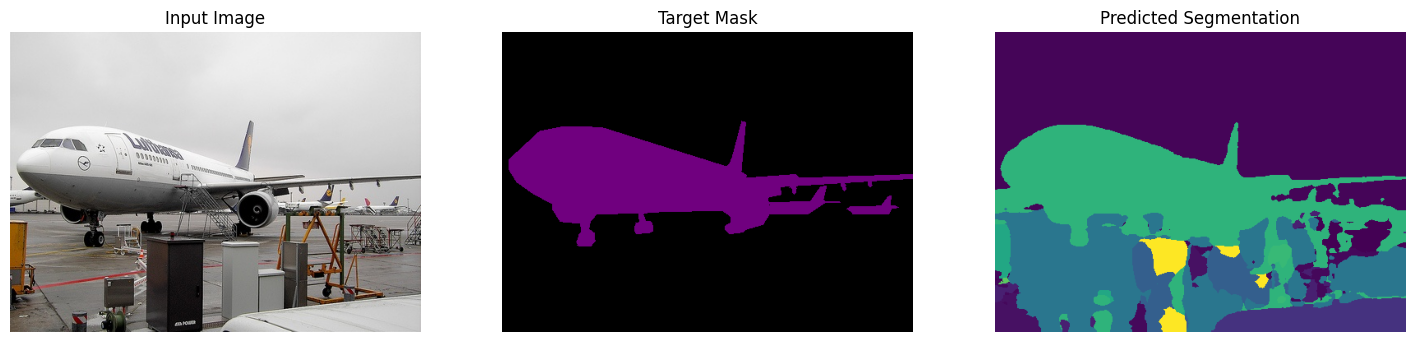

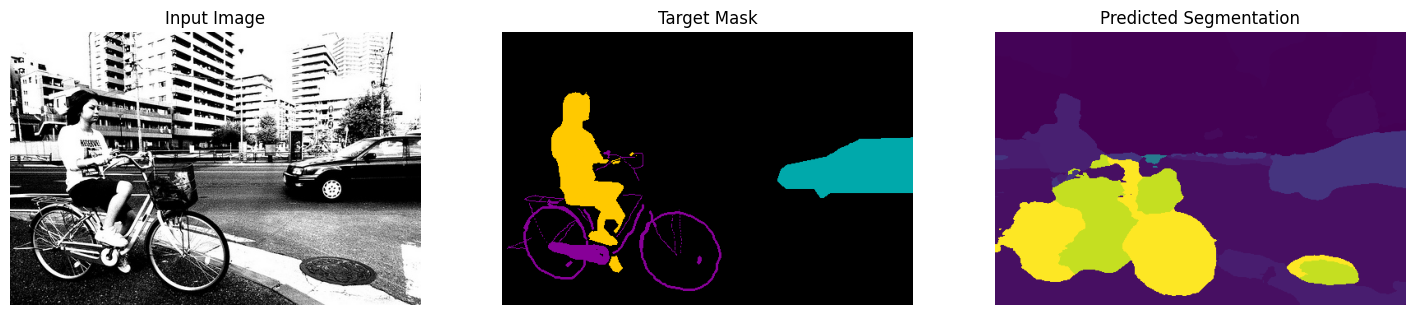

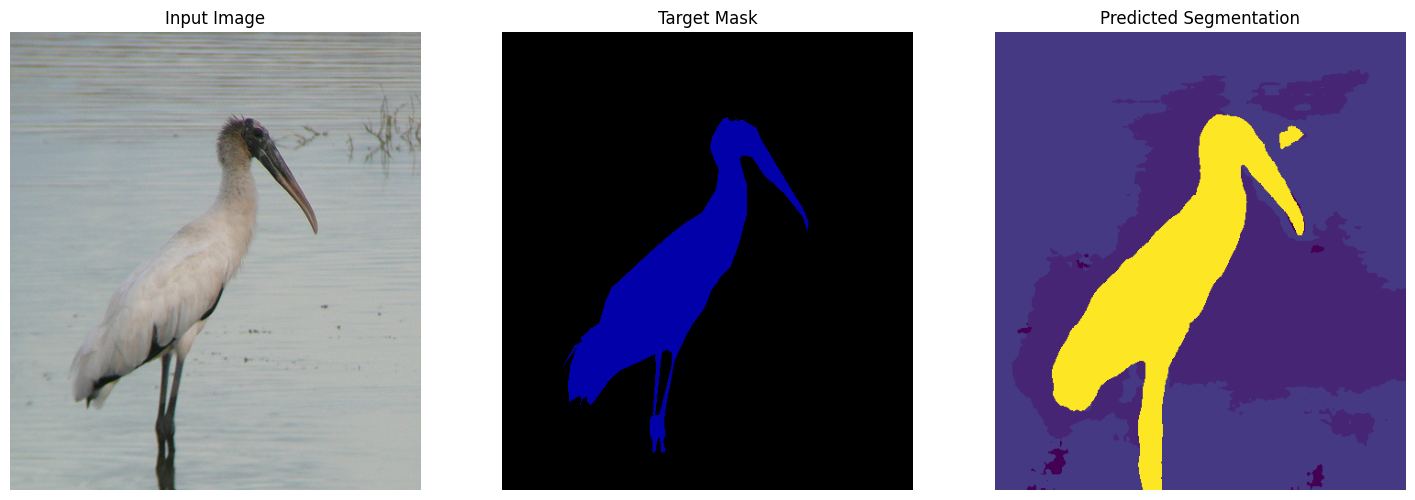

In [6]:
for idx in [0, 666, 999]:  # example indices to visualize
    image, target = dataset[idx]
    inputs = feature_extractor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits  # (batch_size, num_classes, height, width)
        upsampled_logits = torch.nn.functional.interpolate(
            logits,
            size=image.size[::-1],  # (height, width)
            mode="bilinear",
            align_corners=False,
        )
        pred_seg = upsampled_logits.argmax(dim=1)[0].cpu().numpy()
    # Convert target mask to numpy array
    target_mask = np.array(target)
    show_result(image, pred_seg, target_mask)

SegFormer from HuggingFace is trained on ADE20K, which has 150 classes, while VOC2012 has only 20 classes. So, without finetuning on VOC2012, the predicted class indices do not correspond to VOC classes.